In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn import metrics
import os
import fiona

In [2]:
fire_data = gpd.read_file("../total_fire.geojson")
ain_data = gpd.read_file("../datasets_par_departement/departement-01-ain-original.geojson")
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
yvelines_data = gpd.read_file("../datasets_par_departement/departement-78-yvelines-original.geojson")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

In [4]:
def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

In [5]:
def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

In [6]:
fire_data = calculer_duree(fire_data, 'date_debut', 'date_fin')
fire_data['centroid'] = fire_data.geometry.centroid
fire_data['centroid_lon'] = fire_data['centroid'].x
fire_data['centroid_lat'] = fire_data['centroid'].y
fire_data['date_debut'] = pd.to_datetime(fire_data['date_debut'], errors='coerce')
fire_data['hour'] = fire_data['date_debut'].dt.hour
fire_data['date'] = pd.to_datetime(fire_data['date'], errors='coerce')
fire_data['month'] = fire_data['date'].dt.month
fire_data['duree'] = pd.to_timedelta(fire_data['duree'], errors='coerce')
fire_data['duree_minutes'] = fire_data['duree'].dt.total_seconds() / 60
fire_data['weekday'] = fire_data['date'].dt.weekday
fire_data['season'] = fire_data['month'].apply(season_encoding)

doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['season'] = doubs_data['month'].apply(season_encoding)

ain_data = calculer_duree(ain_data, 'date_debut', 'date_fin')
ain_data['centroid'] = ain_data.geometry.centroid
ain_data['centroid_lon'] = ain_data['centroid'].x
ain_data['centroid_lat'] = ain_data['centroid'].y
ain_data['date_debut'] = pd.to_datetime(ain_data['date_debut'], errors='coerce')
ain_data['hour'] = ain_data['date_debut'].dt.hour
ain_data['date'] = pd.to_datetime(ain_data['date'], errors='coerce')
ain_data['month'] = ain_data['date'].dt.month
ain_data['weekday'] = ain_data['date'].dt.weekday
ain_data['season'] = ain_data['month'].apply(season_encoding)

yvelines_data = calculer_duree(yvelines_data, 'date_debut', 'date_fin')
yvelines_data['centroid'] = yvelines_data.geometry.centroid
yvelines_data['centroid_lon'] = yvelines_data['centroid'].x
yvelines_data['centroid_lat'] = yvelines_data['centroid'].y
yvelines_data['date_debut'] = pd.to_datetime(yvelines_data['date_debut'], errors='coerce')
yvelines_data['hour'] = yvelines_data['date_debut'].dt.hour
yvelines_data['date'] = pd.to_datetime(yvelines_data['date'], errors='coerce')
yvelines_data['month'] = yvelines_data['date'].dt.month
yvelines_data['weekday'] = yvelines_data['date'].dt.weekday
yvelines_data['season'] = yvelines_data['month'].apply(season_encoding)

<ipython-input-6-f0b724ebf8af>:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  fire_data['centroid'] = fire_data.geometry.centroid
<ipython-input-6-f0b724ebf8af>:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  doubs_data['centroid'] = doubs_data.geometry.centroid
<ipython-input-6-f0b724ebf8af>:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ain_data['centroid'] = ain_data.geometry.centroid
<ipython-input-6-f0b724ebf8af>:37: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to

In [7]:
test_data = yvelines_data.copy()

In [8]:
features = ['centroid_lon', 'centroid_lat', 'hour', 'month', 'departement']
target = 'duree_minutes'

In [10]:
cut_1 = test_data[target].quantile(0.9)
cut_2 = 30

filtered_data = test_data[(test_data[target] <= cut_1)]

removed_data = test_data[(test_data[target] > cut_1)]

test_data = filtered_data.copy()

print(f"Nombre de lignes conservées : {len(filtered_data)}")
print(f"Nombre de lignes supprimées : {len(removed_data)}")

Nombre de lignes conservées : 2580
Nombre de lignes supprimées : 286


In [11]:
X = filtered_data[features]
y = filtered_data[target]

numeric_features = ['centroid_lon', 'centroid_lat', 'hour']
categorical_features = ['departement', 'month']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ridge', Ridge(alpha=1))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ridge_pipeline.fit(X_train, y_train)

y_pred = ridge_pipeline.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Squared Error (MSE): 497.03
Root Mean Squared Error (RMSE): 22.29
Mean Absolute Error (MAE): 17.85
R² Score: 0.03


In [12]:
print("------------------------------------------------------------MinMax---------------------------------------------------------")

------------------------------------------------------------MinMax---------------------------------------------------------


In [9]:
scaler = MinMaxScaler()

df = filtered_data.copy()

features = ['centroid_lon', 'centroid_lat', 'hour', 'month']
target = 'duree_minutes'

df["duree_minutes_scaled"] = scaler.fit_transform(df[[target]])

X = df[features]
y = df['duree_minutes_scaled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2 : {r2:.2f}")

NameError: name 'filtered_data' is not defined

In [14]:
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test.values.reshape(-1, 1))

results = pd.DataFrame({
    'Réalité': y_test_original.flatten(),
    'Prédiction': y_pred_original.flatten()
})
print(results)

     Réalité  Prédiction
0       96.0   47.246513
1       30.0   42.265366
2       80.0   48.740637
3       14.0   45.049037
4       26.0   43.870987
..       ...         ...
769     31.0   45.779859
770      8.0   48.315686
771     47.0   50.672223
772     57.0   40.483286
773     64.0   51.419164

[774 rows x 2 columns]


In [15]:
mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
rmse = mse ** 0.5
r2 = r2_score(y_test_original, y_pred_original)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2 : {r2:.2f}")

MAE : 17.84
MSE : 495.74
RMSE : 22.27
R^2 : 0.03


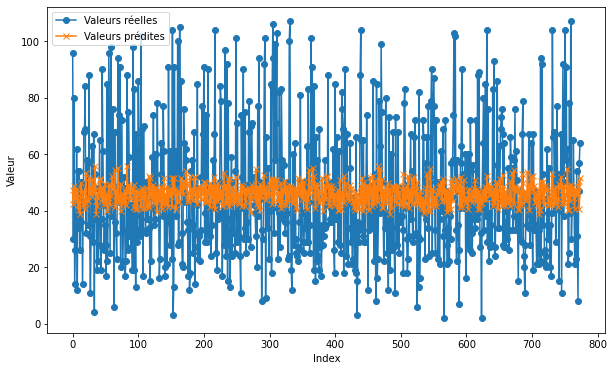

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='Valeurs réelles', marker='o')
plt.plot(y_pred_original, label='Valeurs prédites', marker='x')
plt.xlabel("Index")
plt.ylabel("Valeur")
plt.legend()
plt.show()

In [17]:
df['interval'] = pd.cut(df['duree_minutes_scaled'], bins=[i/10 for i in range(11)], include_lowest=True)

print("\nDataset avec colonnes d'intervalles :")
print(df[['duree_minutes_scaled', 'interval']])


Dataset avec colonnes d'intervalles :
      duree_minutes_scaled    interval
0                 0.240741  (0.2, 0.3]
1                 0.277778  (0.2, 0.3]
2                 0.222222  (0.2, 0.3]
3                 0.703704  (0.7, 0.8]
4                 0.231481  (0.2, 0.3]
...                    ...         ...
2860              0.305556  (0.3, 0.4]
2861              0.527778  (0.5, 0.6]
2862              0.185185  (0.1, 0.2]
2863              0.833333  (0.8, 0.9]
2865              0.962963  (0.9, 1.0]

[2580 rows x 2 columns]


In [18]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
df['predicted_scaled'] = ridge_model.predict(X)

In [19]:
df['target_original'] = scaler.inverse_transform(df[['duree_minutes_scaled']])
df['predicted_original'] = scaler.inverse_transform(df[['predicted_scaled']])

print("Valeurs originales :")
print(df[['target_original', 'predicted_original']])

Valeurs originales :
      target_original  predicted_original
0                26.0           46.620928
1                30.0           52.211674
2                24.0           46.116792
3                76.0           52.552279
4                25.0           45.513900
...               ...                 ...
2860             33.0           40.907835
2861             57.0           46.307439
2862             20.0           48.096019
2863             90.0           47.193721
2865            104.0           52.437566

[2580 rows x 2 columns]


In [20]:
errors_by_interval = []

for interval, group in df.groupby('interval'):
    # Calcul des métriques
    mae = mean_absolute_error(group['target_original'], group['predicted_original'])
    mse = mean_squared_error(group['target_original'], group['predicted_original'])
    rmse = np.sqrt(mse)
    max_value = group['target_original'].max()  # Trouver la valeur maximale

    # Ajouter les informations dans le tableau final
    errors_by_interval.append({
        'Interval': interval,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'Max_Target_Value': max_value  # Ajouter la valeur maximale
    })

# Transformer les résultats en DataFrame
error_df = pd.DataFrame(errors_by_interval)

# Afficher les erreurs
print("\nErreurs par intervalle :")
print(error_df)


Erreurs par intervalle :
        Interval        MAE          MSE       RMSE  Max_Target_Value
0  (-0.001, 0.1]  40.607215  1661.565152  40.762301              10.0
1     (0.1, 0.2]  28.259700   819.514987  28.627172              21.0
2     (0.2, 0.3]  18.001001   341.905820  18.490696              32.0
3     (0.3, 0.4]   8.152541    86.030782   9.275278              43.0
4     (0.4, 0.5]   4.065663    25.359113   5.035783              54.0
5     (0.5, 0.6]  12.377825   171.760626  13.105748              64.0
6     (0.6, 0.7]  22.923875   549.449598  23.440341              75.0
7     (0.7, 0.8]  34.134583  1184.415444  34.415337              86.0
8     (0.8, 0.9]  44.182685  1973.621487  44.425460              97.0
9     (0.9, 1.0]  54.945583  3041.420427  55.149075             108.0


In [21]:
print("-------------------------------------------------------Ridge Regression----------------------------------------------------")

-------------------------------------------------------Ridge Regression----------------------------------------------------


In [22]:
test_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,duree_minutes,geometry,duree,centroid,centroid_lon,centroid_lat,hour,month,weekday,season
0,871fb4440ffffff,NATURELS,2017-01-16 17:17:30,2017-01-16 17:44:23,1.0,2017.0,2017-01-16,departement-78-yvelines,26,"POLYGON ((1.83801 48.94398, 1.82403 48.93712, ...",0 days 00:26:53,POINT (1.84047 48.93160),1.840467,48.931599,17,1,0,0
1,871fb6b73ffffff,NATURELS,2017-01-19 20:10:51,2017-01-19 20:41:17,1.0,2017.0,2017-01-19,departement-78-yvelines,30,"POLYGON ((1.82875 48.68099, 1.81482 48.67409, ...",0 days 00:30:26,POINT (1.83120 48.66858),1.831196,48.668582,20,1,3,0
2,871fb478affffff,NATURELS,2017-01-20 17:18:01,2017-01-20 17:42:06,1.0,2017.0,2017-01-20,departement-78-yvelines,24,"POLYGON ((2.03782 48.78412, 2.02387 48.77727, ...",0 days 00:24:05,POINT (2.04022 48.77173),2.040218,48.771733,17,1,4,0
3,871fb6b29ffffff,NATURELS,2017-01-26 17:48:26,2017-01-26 19:04:34,1.0,2017.0,2017-01-26,departement-78-yvelines,76,"POLYGON ((1.76074 48.71540, 1.74681 48.70849, ...",0 days 01:16:08,POINT (1.76320 48.70299),1.763205,48.702993,17,1,3,0
4,871fb478affffff,NATURELS,2017-01-27 09:53:45,2017-01-27 10:18:56,1.0,2017.0,2017-01-27,departement-78-yvelines,25,"POLYGON ((2.03782 48.78412, 2.02387 48.77727, ...",0 days 00:25:11,POINT (2.04022 48.77173),2.040218,48.771733,9,1,4,0


In [10]:
X_numerical = test_data[['centroid_lon', 'centroid_lat']]
X_categorical = test_data[['hour', 'month', 'weekday', 'season']]
y = test_data['duree_minutes']

X_train, X_test, y_train, y_test = train_test_split(X_numerical.join(X_categorical), y, test_size=0.3, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('geo_poly', Pipeline([
            ('poly', PolynomialFeatures(degree=2, include_bias=False)),
            ('passthrough', 'passthrough')
        ]), ['centroid_lon', 'centroid_lat']),
        ('hour', FunctionTransformer(cyclical_encoding, kw_args={'max_value': 23}), ['hour']),
        ('month', FunctionTransformer(cyclical_encoding, kw_args={'max_value': 12}), ['month']),
        ('weekday', FunctionTransformer(cyclical_encoding, kw_args={'max_value': 6}), ['weekday']),
        ('season', FunctionTransformer(cyclical_encoding, kw_args={'max_value': 3}), ['season'])
    ])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ridge', Ridge(alpha=0.1))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R^2 : {r2:.2f}")

MAE: 39.54967072962527
MSE: 9523.029790971295
RMSE: 97.58601227107958
R^2 : 0.02


In [39]:
print("-----------------------------------------------------------Log-------------------------------------------------------------")

-----------------------------------------------------------Log-------------------------------------------------------------


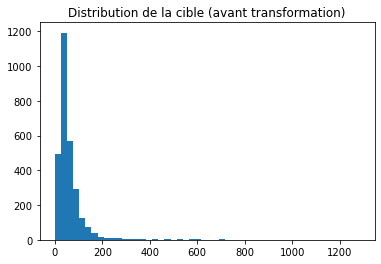

In [11]:
plt.hist(y, bins=50)
plt.title("Distribution de la cible (avant transformation)")
plt.show()

In [12]:
y_log = np.log1p(y)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_numerical.join(X_categorical), y, test_size=0.3, random_state=42)
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('geo_poly',
                                                  Pipeline(steps=[('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('passthrough',
                                                                   'passthrough')]),
                                                  ['centroid_lon',
                                                   'centroid_lat']),
                                                 ('hour',
                                                  FunctionTransformer(func=<function cyclical_encoding at 0x7f9e300725e0>,
                                                                      kw_args={'max_value': 23}),
                                                  ['hour']),
                                                 ('month',
                                                  FunctionTransformer(func=<function cyclical_encoding at 0x7f9e300725e0>,
                                                                      kw_args={'max_value': 12}),
                                                  ['month']),
                                                 ('weekday',
                                                  FunctionTransformer(func=<function cyclical_encoding at 0x7f9e300725e0>,
                                                                      kw_args={'max_value': 6}),
                                                  ['weekday']),
                                                 ('season',
                                                  FunctionTransformer(func=<function cyclical_encoding at 0x7f9e300725e0>,
                                                                      kw_args={'max_value': 3}),
                                                  ['season'])])),
                ('ridge', Ridge(alpha=0.1))])

In [15]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

In [19]:
print("Valeurs maximales dans y_test :", np.max(y_test))
print("Valeurs minimales dans y_test :", np.min(y_test))

Valeurs maximales dans y_test : 1283
Valeurs minimales dans y_test : 1


In [22]:
print("Valeur max avant transformation (y_test brut) :", np.max(np.expm1(y_test)))

Valeur max avant transformation (y_test brut) : inf


/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/pandas/core/series.py:726: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [23]:
print("Valeur max après transformation (y_test log) :", np.max(y_test))

Valeur max après transformation (y_test log) : 1283


In [24]:
test_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,duree_minutes,geometry,duree,centroid,centroid_lon,centroid_lat,hour,month,weekday,season
0,871fb4440ffffff,NATURELS,2017-01-16 17:17:30,2017-01-16 17:44:23,1.0,2017.0,2017-01-16,departement-78-yvelines,26,"POLYGON ((1.83801 48.94398, 1.82403 48.93712, ...",0 days 00:26:53,POINT (1.84047 48.93160),1.840467,48.931599,17,1,0,0
1,871fb6b73ffffff,NATURELS,2017-01-19 20:10:51,2017-01-19 20:41:17,1.0,2017.0,2017-01-19,departement-78-yvelines,30,"POLYGON ((1.82875 48.68099, 1.81482 48.67409, ...",0 days 00:30:26,POINT (1.83120 48.66858),1.831196,48.668582,20,1,3,0
2,871fb478affffff,NATURELS,2017-01-20 17:18:01,2017-01-20 17:42:06,1.0,2017.0,2017-01-20,departement-78-yvelines,24,"POLYGON ((2.03782 48.78412, 2.02387 48.77727, ...",0 days 00:24:05,POINT (2.04022 48.77173),2.040218,48.771733,17,1,4,0
3,871fb6b29ffffff,NATURELS,2017-01-26 17:48:26,2017-01-26 19:04:34,1.0,2017.0,2017-01-26,departement-78-yvelines,76,"POLYGON ((1.76074 48.71540, 1.74681 48.70849, ...",0 days 01:16:08,POINT (1.76320 48.70299),1.763205,48.702993,17,1,3,0
4,871fb478affffff,NATURELS,2017-01-27 09:53:45,2017-01-27 10:18:56,1.0,2017.0,2017-01-27,departement-78-yvelines,25,"POLYGON ((2.03782 48.78412, 2.02387 48.77727, ...",0 days 00:25:11,POINT (2.04022 48.77173),2.040218,48.771733,9,1,4,0
